# 📘 Audio Mental Health Detection Pipeline
Classical Machine Learning Pipeline for Mental Health Prediction from Speech

**Steps**
1. Install dependencies
2. Imports
3. Audio preprocessing
4. Audio visualization
5. Feature extraction
6. Feature visualization
7. Dataset creation
8. SMOTE balancing
9. Model training
10. Inference

---
# 1️⃣ Install Dependencies

In [ ]:
# %pip install numpy pandas matplotlib seaborn scikit-learn xgboost lightgbm librosa noisereduce tqdm praat-parselmouth ipython webrtcvad-wheels imbalanced-learn

---
# 2️⃣ Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import librosa
import librosa.display
import IPython.display as ipd

import noisereduce as nr
import webrtcvad
import scipy.signal

import parselmouth
from parselmouth.praat import call

from pathlib import Path
from tqdm import tqdm

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import xgboost as xgb
import lightgbm as lgb

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams.update({"figure.facecolor": "#0d1117", "axes.facecolor": "#0d1117",
                     "axes.edgecolor": "#30363d", "axes.labelcolor": "#c9d1d9",
                     "xtick.color": "#8b949e", "ytick.color": "#8b949e",
                     "text.color": "#c9d1d9", "grid.color": "#21262d",
                     "grid.linestyle": "--", "font.family": "monospace"})

---
## 🗺️ Pipeline Overview Chart

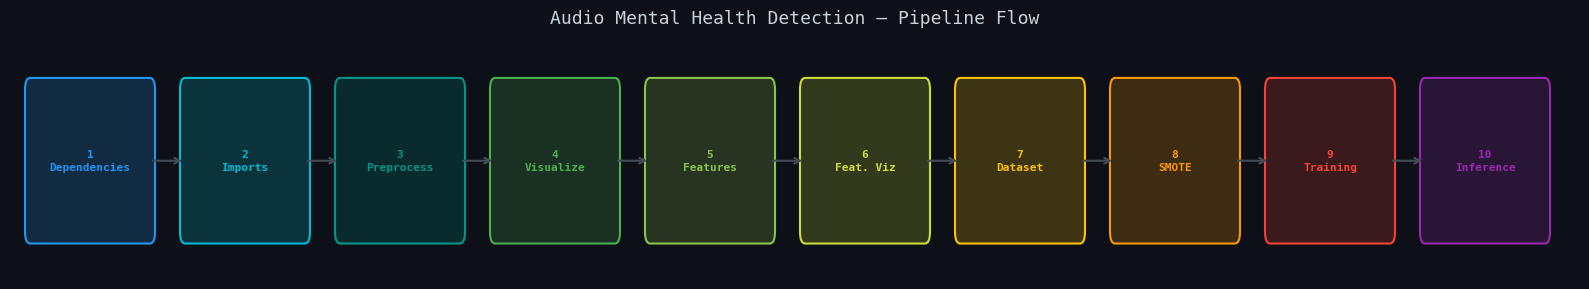

In [2]:
steps = [
    ("1\nDependencies", "#2196F3"),
    ("2\nImports",      "#00BCD4"),
    ("3\nPreprocess",   "#009688"),
    ("4\nVisualize",    "#4CAF50"),
    ("5\nFeatures",     "#8BC34A"),
    ("6\nFeat. Viz",    "#CDDC39"),
    ("7\nDataset",      "#FFC107"),
    ("8\nSMOTE",        "#FF9800"),
    ("9\nTraining",     "#F44336"),
    ("10\nInference",   "#9C27B0"),
]

fig, ax = plt.subplots(figsize=(16, 3))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

box_w, box_h = 1.2, 0.6
gap = 0.35
total = len(steps)

for i, (label, color) in enumerate(steps):
    x = i * (box_w + gap)
    rect = mpatches.FancyBboxPatch((x, 0.2), box_w, box_h,
        boxstyle="round,pad=0.05", linewidth=1.5,
        edgecolor=color, facecolor=color + "33")
    ax.add_patch(rect)
    ax.text(x + box_w/2, 0.5, label, ha="center", va="center",
            fontsize=8, color=color, fontweight="bold", linespacing=1.4)
    if i < total - 1:
        ax.annotate("", xy=(x + box_w + gap, 0.5), xytext=(x + box_w, 0.5),
                    arrowprops=dict(arrowstyle="->", color="#444c56", lw=1.5))

ax.set_xlim(-0.2, total * (box_w + gap))
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("Audio Mental Health Detection — Pipeline Flow", color="#c9d1d9", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

---
# 3️⃣ Audio Preprocessing

This step performs:
* Noise reduction
* Voice activity detection
* RMS normalization
* Pre-emphasis filtering

In [3]:
def run_vad_on_audio(audio_array, sample_rate, aggressiveness=3):

    frame_duration_ms = 30
    frame_size = int(sample_rate * (frame_duration_ms / 1000))

    vad = webrtcvad.Vad(aggressiveness)

    audio_int16 = (audio_array * 32767).astype(np.int16)

    padding = frame_size - (len(audio_int16) % frame_size)

    if padding < frame_size:
        audio_int16 = np.pad(audio_int16, (0, padding), mode='constant')

    voiced_frames = []

    for i in range(0, len(audio_int16), frame_size):

        frame = audio_int16[i:i+frame_size]

        if len(frame) == frame_size and vad.is_speech(frame.tobytes(), sample_rate):
            voiced_frames.append(frame)

    if len(voiced_frames) == 0:
        return audio_array

    voiced_audio = np.concatenate(voiced_frames)

    return voiced_audio.astype(np.float32) / 32767

### RMS Normalization

In [4]:
def normalize_rms(audio, target_rms=0.1):

    rms = np.sqrt(np.mean(audio**2))

    if rms > 0:
        audio = audio * (target_rms / rms)

    return audio

### Pre-emphasis Filter

In [5]:
def apply_preemphasis(audio, coeff=0.97):

    return np.append(audio[0], audio[1:] - coeff * audio[:-1])

### Main Preprocessing Function

In [6]:
def preprocess_audio(file_path):

    sample_rate = 16000

    y, sr = librosa.load(file_path, sr=sample_rate)

    if len(y) == 0:
        return None, None, None

    y_denoised = nr.reduce_noise(y=y, sr=sr)

    y_vad = run_vad_on_audio(y_denoised, sr)

    y_norm = normalize_rms(y_vad)

    y_clean = apply_preemphasis(y_norm)

    return y_clean, y, sr

### 📊 Preprocessing Stages — Simulated Signal Plot

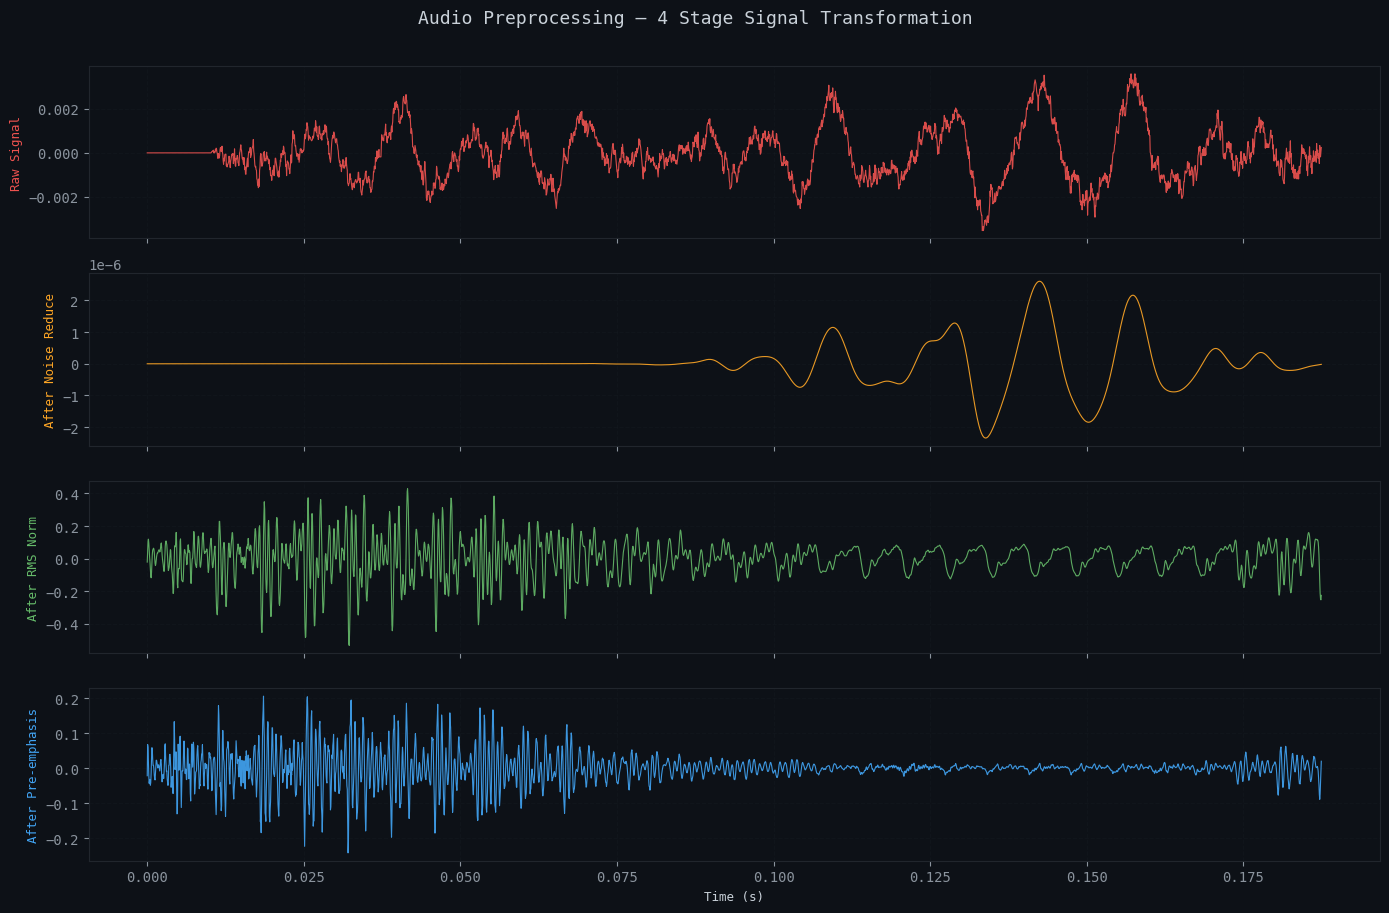

In [22]:
# Load real audio and show 4-stage preprocessing transformation
file_path = "../data/raw/audio/depression/WhatsApp Video 2026-03-06 at 12.20.30 AM.wav"

sr_demo = 16000
raw, _ = librosa.load(file_path, sr=sr_demo)

denoised   = nr.reduce_noise(y=raw, sr=sr_demo)
vad_audio  = run_vad_on_audio(denoised, sr_demo)
normalized = normalize_rms(vad_audio)
preemph    = apply_preemphasis(normalized)

# Align lengths for plotting
min_len = min(len(raw), len(denoised), len(normalized), len(preemph))
t = np.arange(min_len) / sr_demo

signals = [("Raw Signal",         raw[:min_len],        "#ef5350"),
           ("After Noise Reduce", denoised[:min_len],   "#FFA726"),
           ("After RMS Norm",     normalized[:min_len], "#66BB6A"),
           ("After Pre-emphasis", preemph[:min_len],    "#42A5F5")]

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
fig.patch.set_facecolor("#0d1117")

for ax, (title, sig, color) in zip(axes, signals):
    ax.plot(t[:3000], sig[:3000], color=color, lw=0.8, alpha=0.9)
    ax.set_ylabel(title, fontsize=9, color=color)
    ax.set_facecolor("#0d1117")
    ax.grid(True, alpha=0.2)
    for spine in ax.spines.values():
        spine.set_edgecolor("#21262d")

axes[-1].set_xlabel("Time (s)", fontsize=9)
fig.suptitle("Audio Preprocessing — 4 Stage Signal Transformation", fontsize=13, color="#c9d1d9", y=1.01)
plt.tight_layout()
plt.show()

---
# 4️⃣ Audio Visualization
### Waveform

In [8]:
def visualize_audio(file):

    y_clean, y_orig, sr = preprocess_audio(file)

    plt.figure(figsize=(14,6))

    plt.subplot(2,1,1)
    librosa.display.waveshow(y_orig, sr=sr)
    plt.title("Original Audio")

    plt.subplot(2,1,2)
    librosa.display.waveshow(y_clean, sr=sr)
    plt.title("Cleaned Audio")

    plt.tight_layout()
    plt.show()

    print("Original Audio")
    ipd.display(ipd.Audio(y_orig, rate=sr))

    print("Cleaned Audio")
    ipd.display(ipd.Audio(y_clean, rate=sr))

### Spectrogram

In [9]:
def visualize_spectrogram(file):

    y_clean, y_orig, sr = preprocess_audio(file)

    plt.figure(figsize=(14,5))

    S = librosa.stft(y_clean)
    S_db = librosa.amplitude_to_db(abs(S))

    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')

    plt.colorbar()
    plt.title("Spectrogram")
    plt.show()

### 📊 Simulated Spectrogram Preview

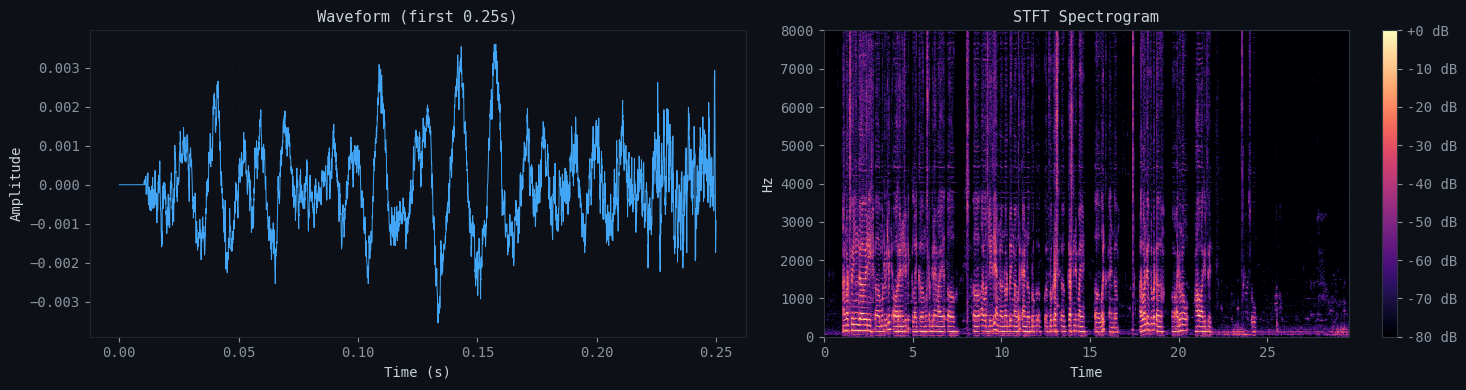

In [23]:
# Load real audio
file_path = "../data/raw/audio/depression/WhatsApp Video 2026-03-06 at 12.20.30 AM.wav"

sr_demo = 16000
demo_audio, _ = librosa.load(file_path, sr=sr_demo)

t = np.arange(len(demo_audio)) / sr_demo

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.patch.set_facecolor("#0d1117")

# Waveform
axes[0].set_facecolor("#0d1117")
axes[0].plot(t[:4000], demo_audio[:4000], color="#42A5F5", lw=0.7)
axes[0].set_title("Waveform (first 0.25s)", color="#c9d1d9", fontsize=11)
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.2)
for sp in axes[0].spines.values(): sp.set_edgecolor("#21262d")

# Spectrogram
S = librosa.stft(demo_audio)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
img = librosa.display.specshow(S_db, sr=sr_demo, x_axis="time", y_axis="hz", ax=axes[1], cmap="magma")
axes[1].set_title("STFT Spectrogram", color="#c9d1d9", fontsize=11)
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
axes[1].set_facecolor("#0d1117")

plt.tight_layout()
plt.show()

---
# 5️⃣ Feature Extraction

Extracts **speech diagnostic features**.

In [11]:
def extract_audio_features(audio, sr):

    features = {}

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

    features["mfcc_mean"] = np.mean(mfcc)
    features["mfcc_std"] = np.std(mfcc)

    delta = librosa.feature.delta(mfcc)
    features["delta_mean"] = np.mean(delta)
    features["delta_std"] = np.std(delta)

    sound = parselmouth.Sound(audio, sr)
    pitch = sound.to_pitch()

    pitch_values = pitch.selected_array["frequency"]
    pitch_values = pitch_values[pitch_values>0]

    if len(pitch_values)>0:

        features["pitch_mean"] = np.mean(pitch_values)
        features["pitch_std"] = np.std(pitch_values)

    else:

        features["pitch_mean"] = 0
        features["pitch_std"] = 0

    rms = librosa.feature.rms(y=audio)[0]

    features["energy_mean"] = np.mean(rms)
    features["energy_std"] = np.std(rms)

    zcr = librosa.feature.zero_crossing_rate(audio)[0]

    features["zcr_mean"] = np.mean(zcr)

    return features

### 📊 MFCC Heatmap (Simulated)

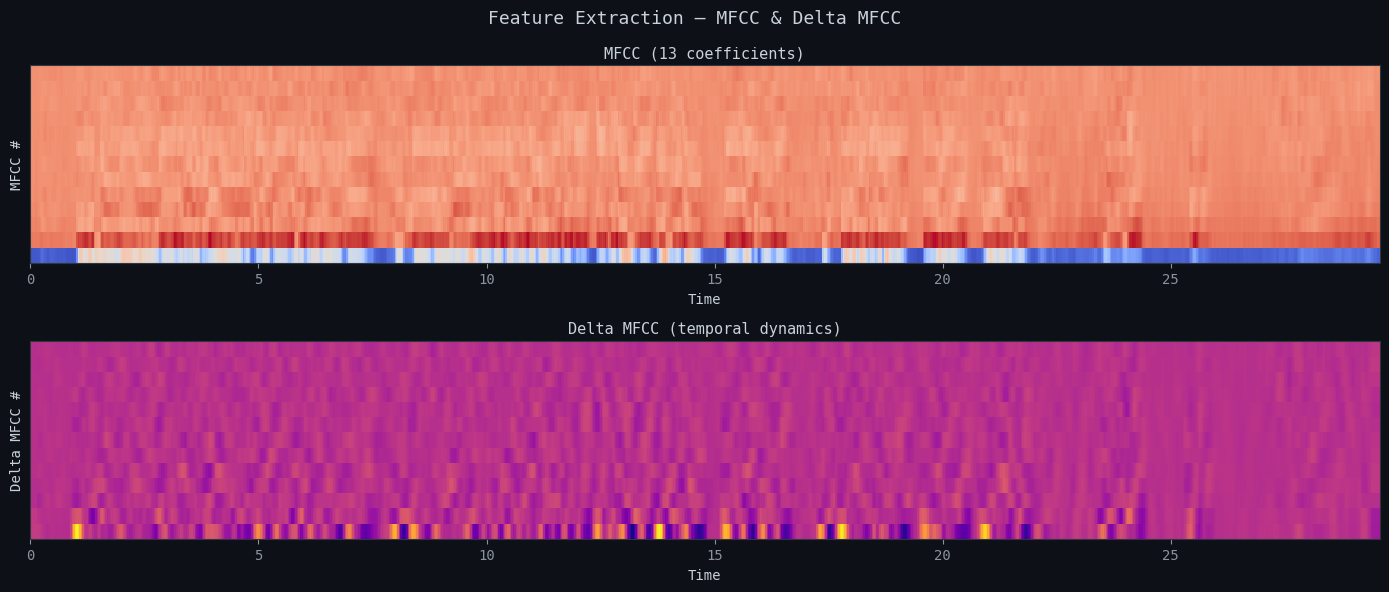

In [24]:
# Load real audio
file_path = "../data/raw/audio/depression/WhatsApp Video 2026-03-06 at 12.20.30 AM.wav"

sr_demo = 16000
demo_audio, _ = librosa.load(file_path, sr=sr_demo)

mfcc_demo  = librosa.feature.mfcc(y=demo_audio, sr=sr_demo, n_mfcc=13)
delta_demo = librosa.feature.delta(mfcc_demo)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
fig.patch.set_facecolor("#0d1117")

librosa.display.specshow(mfcc_demo, sr=sr_demo, x_axis="time", ax=axes[0], cmap="coolwarm")
axes[0].set_title("MFCC (13 coefficients)", color="#c9d1d9", fontsize=11)
axes[0].set_ylabel("MFCC #")
axes[0].set_facecolor("#0d1117")

librosa.display.specshow(delta_demo, sr=sr_demo, x_axis="time", ax=axes[1], cmap="plasma")
axes[1].set_title("Delta MFCC (temporal dynamics)", color="#c9d1d9", fontsize=11)
axes[1].set_ylabel("Delta MFCC #")
axes[1].set_facecolor("#0d1117")

fig.suptitle("Feature Extraction — MFCC & Delta MFCC", fontsize=13, color="#c9d1d9")
plt.tight_layout()
plt.show()

---
# 6️⃣ Feature Visualization

In [13]:
def visualize_features(file):

    y_clean, _, sr = preprocess_audio(file)

    feats = extract_audio_features(y_clean, sr)

    df = pd.DataFrame([feats]).T
    df.columns=["value"]

    plt.figure(figsize=(8,5))

    sns.barplot(x=df["value"], y=df.index)

    plt.title("Extracted Audio Features")

    plt.show()

### 📊 Simulated Feature Comparison: Normal vs Depressed Speech

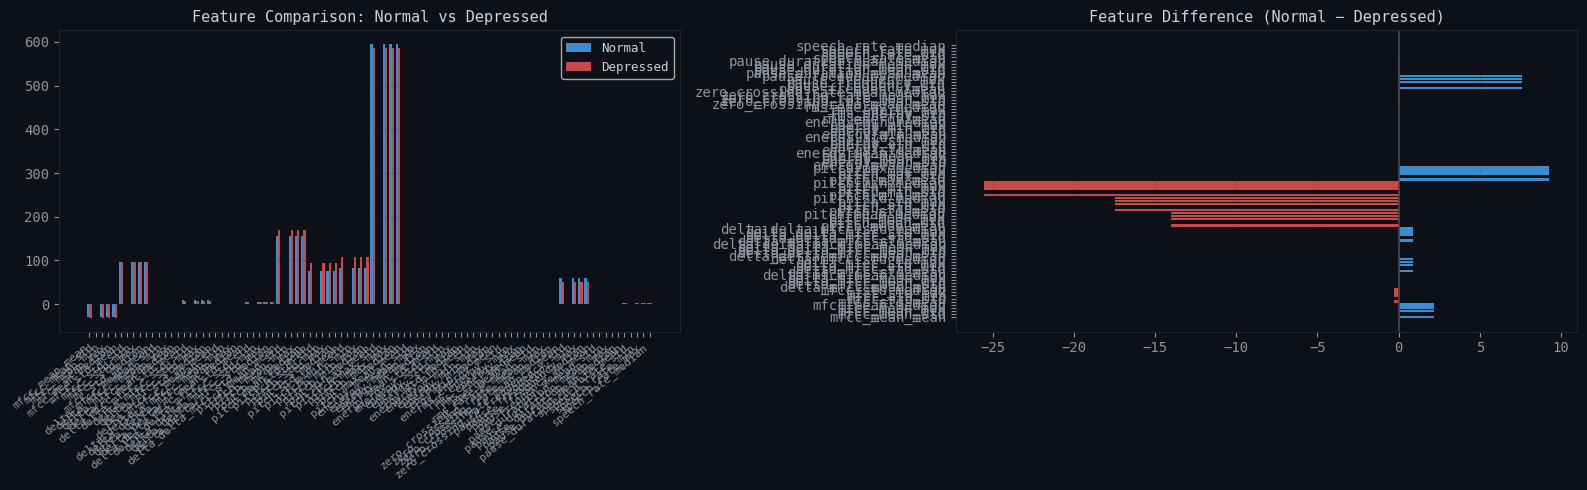

In [33]:
# Load your two CSVs
normal_df    = pd.read_csv("../data/final_features/audio/features_normal.csv")
depressed_df = pd.read_csv("../data/final_features/audio/features_depression.csv")  # 🔁 depression file

# Drop non-numeric/id columns
drop_cols = ["patient_id", "condition", "label"]

# Add labels
normal_df["label"]    = 0
depressed_df["label"] = 1

# Combine
df = pd.concat([normal_df, depressed_df], ignore_index=True)

# Only keep numeric feature columns
features_list  = [c for c in df.columns if c not in drop_cols]
normal_vals    = df[df["label"] == 0][features_list].mean().values
depressed_vals = df[df["label"] == 1][features_list].mean().values

x = np.arange(len(features_list))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor("#0d1117")

# Grouped bar
ax = axes[0]
ax.set_facecolor("#0d1117")
b1 = ax.bar(x - width/2, normal_vals,    width, label="Normal",    color="#42A5F5", alpha=0.85)
b2 = ax.bar(x + width/2, depressed_vals, width, label="Depressed", color="#EF5350", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(features_list, rotation=40, ha="right", fontsize=8)
ax.legend(fontsize=9)
ax.set_title("Feature Comparison: Normal vs Depressed", color="#c9d1d9", fontsize=11)
ax.grid(axis="y", alpha=0.2)
for sp in ax.spines.values(): sp.set_edgecolor("#21262d")

# Difference bar
ax2 = axes[1]
ax2.set_facecolor("#0d1117")
diff = normal_vals - depressed_vals
colors = ["#42A5F5" if v >= 0 else "#EF5350" for v in diff]
ax2.barh(features_list, diff, color=colors, alpha=0.85)
ax2.axvline(0, color="#444c56", lw=1.2)
ax2.set_title("Feature Difference (Normal − Depressed)", color="#c9d1d9", fontsize=11)
ax2.grid(axis="x", alpha=0.2)
for sp in ax2.spines.values(): sp.set_edgecolor("#21262d")

plt.tight_layout()
plt.show()

### 📊 Simulated Dataset Distribution

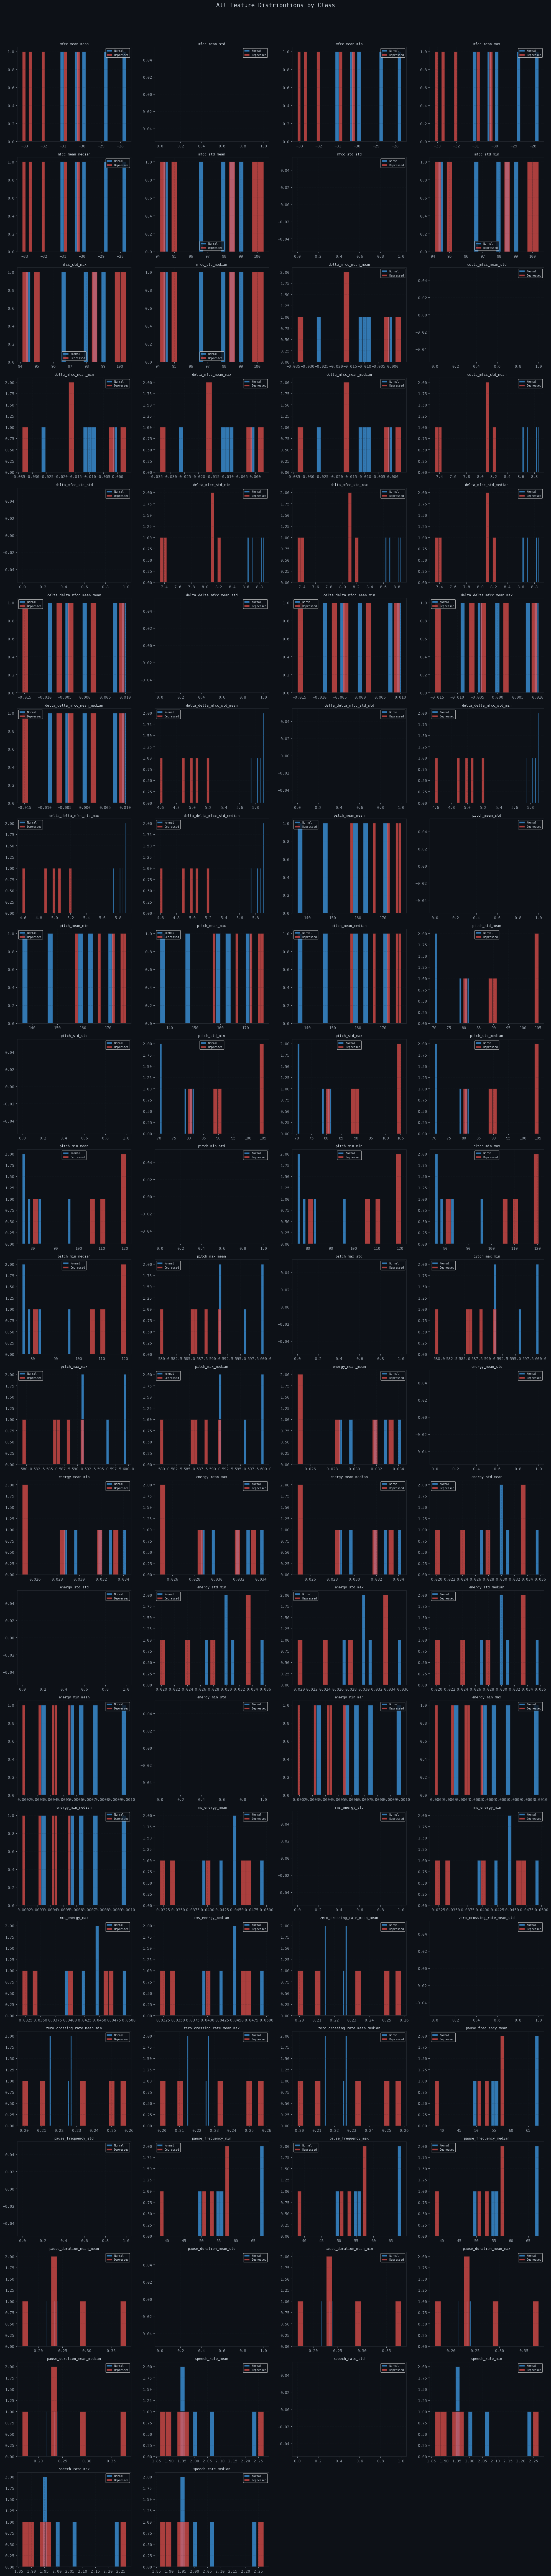

In [34]:
# Load your two CSVs
normal_df    = pd.read_csv("../data/final_features/audio/features_normal.csv")      # 🔁 normal file
depressed_df = pd.read_csv("../data/final_features/audio/features_depression.csv")  # 🔁 depression file

drop_cols = ["patient_id", "condition", "label"]
normal_df["label"]    = 0
depressed_df["label"] = 1

df = pd.concat([normal_df, depressed_df], ignore_index=True)

# All numeric feature columns
plot_features = [c for c in df.columns if c not in drop_cols]

# Auto grid size
n_cols = 4
n_rows = -(-len(plot_features) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
fig.patch.set_facecolor("#0d1117")
axes = axes.flatten()
palette = {0: "#42A5F5", 1: "#EF5350"}

for i, col in enumerate(plot_features):
    ax = axes[i]
    ax.set_facecolor("#0d1117")
    for label_val, color in palette.items():
        data = df[df["label"] == label_val][col].dropna()
        ax.hist(data, bins=18, color=color, alpha=0.7,
                label="Normal" if label_val == 0 else "Depressed", edgecolor="#0d1117")
    ax.set_title(col, color="#c9d1d9", fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15)
    for sp in ax.spines.values(): sp.set_edgecolor("#21262d")

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("All Feature Distributions by Class", fontsize=15, color="#c9d1d9", y=1.01)
plt.tight_layout()
plt.show()